# Market & Industry Analysis

## Objective

This notebook explores startup performance across different industries and markets.

### Key Questions

1. Which markets have the most startups?
2. Which markets attract the most funding?
3. Which markets have the highest average funding per startup?
4. Which markets produce the most acquisitions?
5. Which markets have the highest acquisition rates?

## Business Question

Which industries contain the largest number of startups?

### Why This Matters

Understanding market concentration helps identify the most active startup sectors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../data/raw/investments_VC.csv",
    encoding="latin1"
)

df.columns = df.columns.str.strip()

df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df["funding_total_usd"] = (
    df["funding_total_usd"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.strip()
)

df["funding_total_usd"] = pd.to_numeric(
    df["funding_total_usd"],
    errors="coerce"
)

In [4]:
market_counts = (
    df["market"]
    .dropna()
    .value_counts()
    .head(15)
)

market_counts

market
Software                4620
Biotechnology           3688
Mobile                  1983
E-Commerce              1805
Curated Web             1655
Enterprise Software     1280
Health Care             1207
Clean Technology        1200
Games                   1182
Hardware + Software     1081
Advertising             1064
Health and Wellness      920
Social Media             876
Finance                  867
Education                863
Name: count, dtype: int64

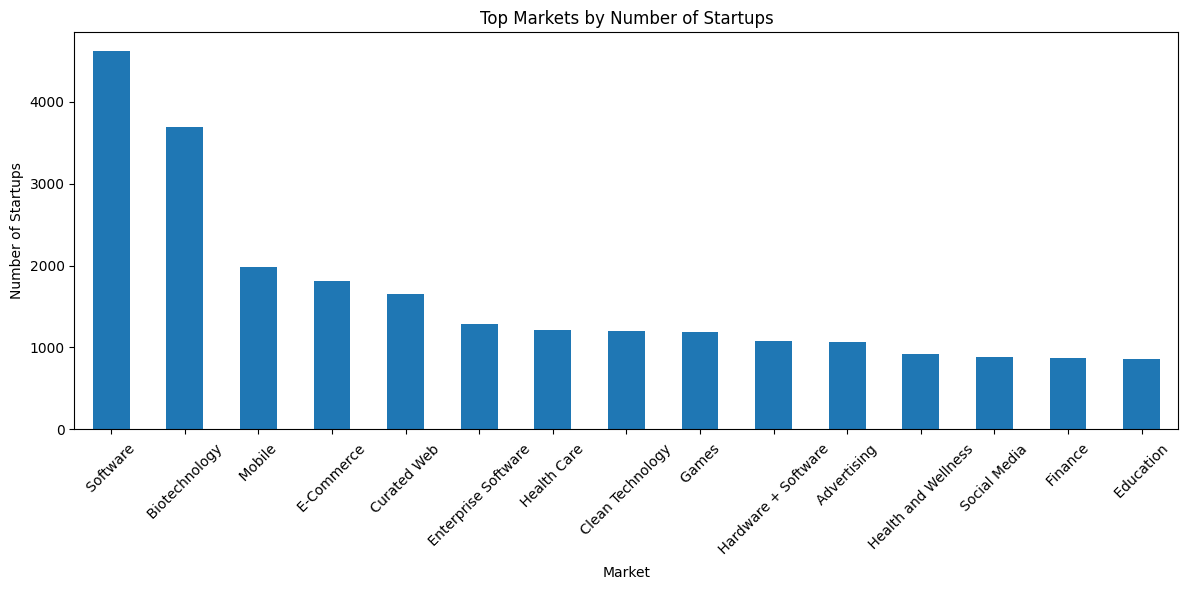

In [5]:
plt.figure(figsize=(12,6))

market_counts.plot(kind="bar")

plt.title("Top Markets by Number of Startups")
plt.xlabel("Market")
plt.ylabel("Number of Startups")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Key Insight: Markets with the Most Startups

### Findings

- Software is the largest startup market in the dataset.
- Biotechnology ranks second, followed by Mobile and E-Commerce.
- Curated Web, Enterprise Software, and Health Care also have large startup populations.

### Interpretation

The dominance of Software reflects the relatively low barriers to entry, scalability, and widespread adoption of software-based business models.

The strong presence of Biotechnology and Health Care indicates significant entrepreneurial activity in research-driven industries, while Mobile and E-Commerce highlight the growth of consumer-focused digital businesses.

### Conclusion

Startup activity is concentrated in technology-driven sectors, with Software serving as the largest startup market.

## Business Question

Which industries receive the largest total amount of startup funding?

### Why This Matters

This helps identify sectors that attract the greatest investor interest.

In [6]:
market_funding = (
    df.groupby("market")["funding_total_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

market_funding

market
Biotechnology           7.337295e+10
Mobile                  4.947011e+10
Software                4.222348e+10
Clean Technology        3.761994e+10
Health Care             2.946608e+10
E-Commerce              2.240839e+10
Enterprise Software     1.929719e+10
Finance                 1.737230e+10
Hardware + Software     1.281293e+10
Advertising             1.266066e+10
Semiconductors          1.234175e+10
Health and Wellness     1.220653e+10
Web Hosting             1.072166e+10
Technology              1.010378e+10
Curated Web             9.587998e+09
Name: funding_total_usd, dtype: float64

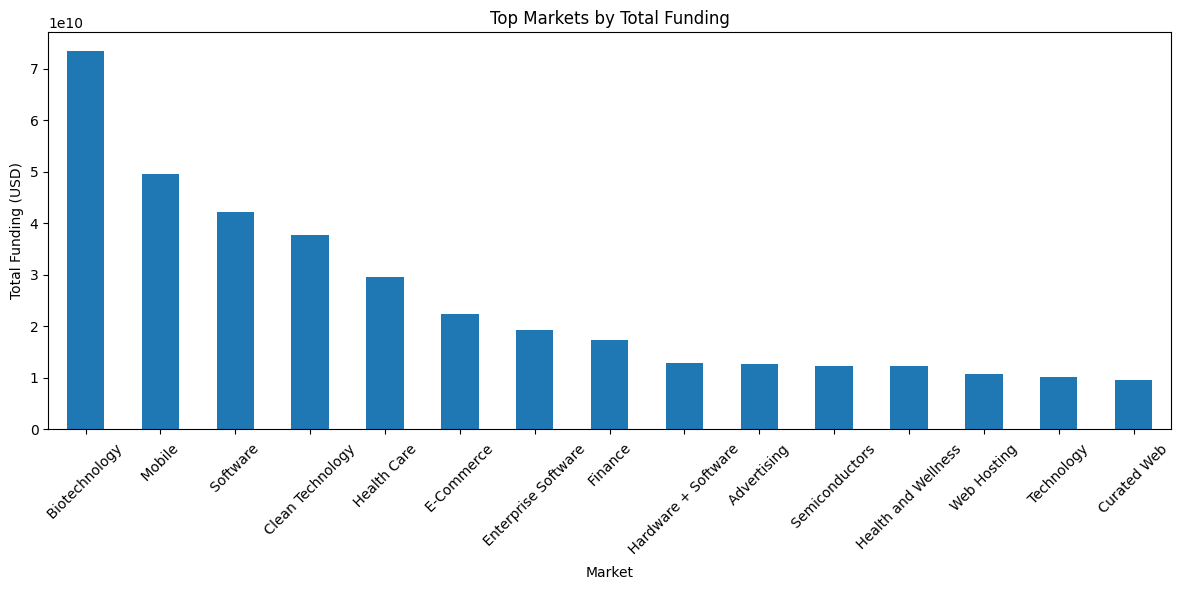

In [7]:
plt.figure(figsize=(12,6))

market_funding.plot(kind="bar")

plt.title("Top Markets by Total Funding")
plt.xlabel("Market")
plt.ylabel("Total Funding (USD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Key Insight: Markets Attracting the Most Funding

### Findings

- Biotechnology attracts the highest total funding.
- Mobile and Software rank second and third respectively.
- Clean Technology and Health Care are also among the most heavily funded sectors.
- Several technology-focused industries dominate the funding rankings.

### Interpretation

While Software contains the largest number of startups, Biotechnology attracts the greatest amount of investment capital.

This suggests that industries such as Biotechnology and Clean Technology require larger investments per company due to research, infrastructure, regulatory requirements, and longer development cycles.

### Conclusion

The industries with the most startups are not necessarily the industries receiving the most funding. Capital-intensive sectors attract larger investments despite having fewer companies.

## Business Question

Which industries receive the highest average funding per startup?

### Why This Matters

Average funding removes the effect of market size and helps identify industries where individual startups attract the largest investments.

In [8]:
market_avg_funding = (
    df.groupby("market")["funding_total_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

market_avg_funding

market
Natural Gas Uses            4.000000e+08
Film Production             2.626750e+08
Oil and Gas                 2.355225e+08
Trading                     1.600852e+08
Content Creators            1.364675e+08
Solar                       1.289295e+08
Recreation                  1.286600e+08
Development Platforms       1.258555e+08
Custom Retail               1.196578e+08
Physicians                  1.182621e+08
Hospitals                   1.105050e+08
B2B Express Delivery        1.050000e+08
Cloud-Based Music           1.040000e+08
Chemicals                   9.066943e+07
Communications Hardware     8.624276e+07
Name: funding_total_usd, dtype: float64

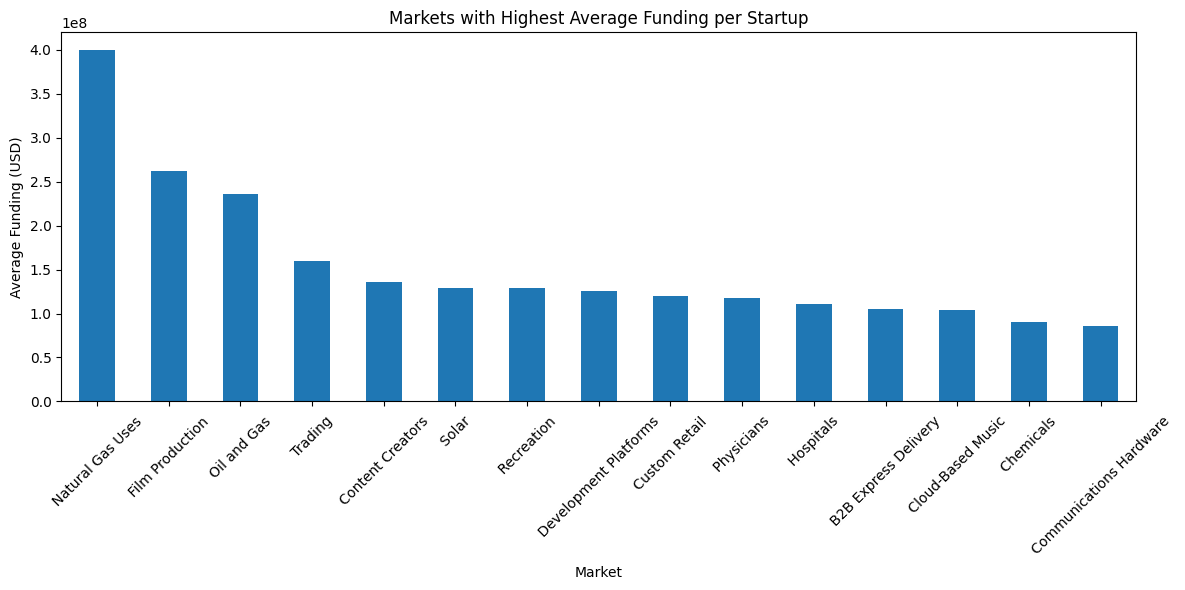

In [9]:
plt.figure(figsize=(12,6))

market_avg_funding.plot(kind="bar")

plt.title("Markets with Highest Average Funding per Startup")
plt.xlabel("Market")
plt.ylabel("Average Funding (USD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Which markets have the highest median funding per startup?

In [11]:
market_median_funding = (
    df.groupby("market")["funding_total_usd"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

market_median_funding

market
Natural Gas Uses                 400000000.0
Film Production                  262675000.0
Recreation                       128660000.0
Custom Retail                    119657790.0
B2B Express Delivery             105000000.0
Cloud-Based Music                104000000.0
Physicians                        82000000.0
TV Production                     50000000.0
Heavy Industry                    45299500.0
Enterprise Resource Planning      44685947.5
Data Center Infrastructure        40000000.0
Advertising Exchanges             38710010.0
Communications Hardware           37805000.0
Space Travel                      37500000.0
Specialty Chemicals               36750000.0
Name: funding_total_usd, dtype: float64

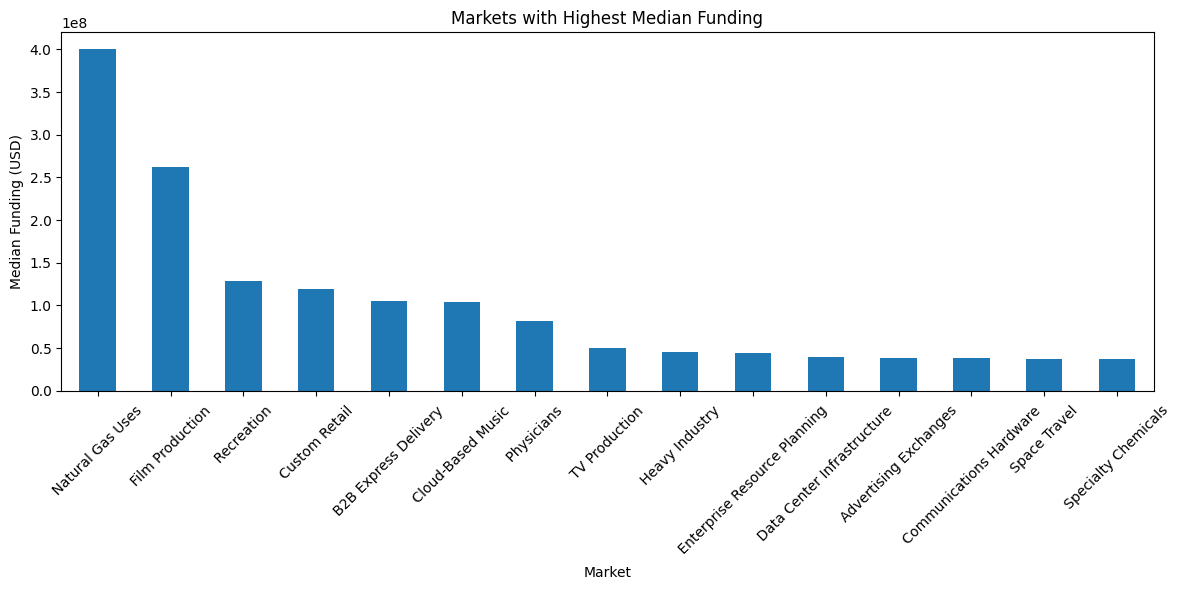

In [12]:
plt.figure(figsize=(12,6))

market_median_funding.plot(kind="bar")

plt.title("Markets with Highest Median Funding")
plt.xlabel("Market")
plt.ylabel("Median Funding (USD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Business Question

Which industries typically go through the most funding rounds?

### Why This Matters

Some industries require longer fundraising journeys due to higher capital requirements, research costs, or longer development cycles.

In [13]:
market_rounds = (
    df.groupby("market")["funding_rounds"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

market_rounds

market
Industrial Energy Efficiency     6.0
PC Gaming                        6.0
Genetic Testing                  5.5
Social Investing                 5.0
Data Center Automation           4.5
Sunglasses                       4.0
Fuels                            4.0
Service Industries               4.0
Rehabilitation                   4.0
Plumbers                         4.0
Google Apps                      4.0
B2B Express Delivery             4.0
Data Privacy                     4.0
Government Innovation            4.0
Face Recognition                 3.5
Name: funding_rounds, dtype: float64

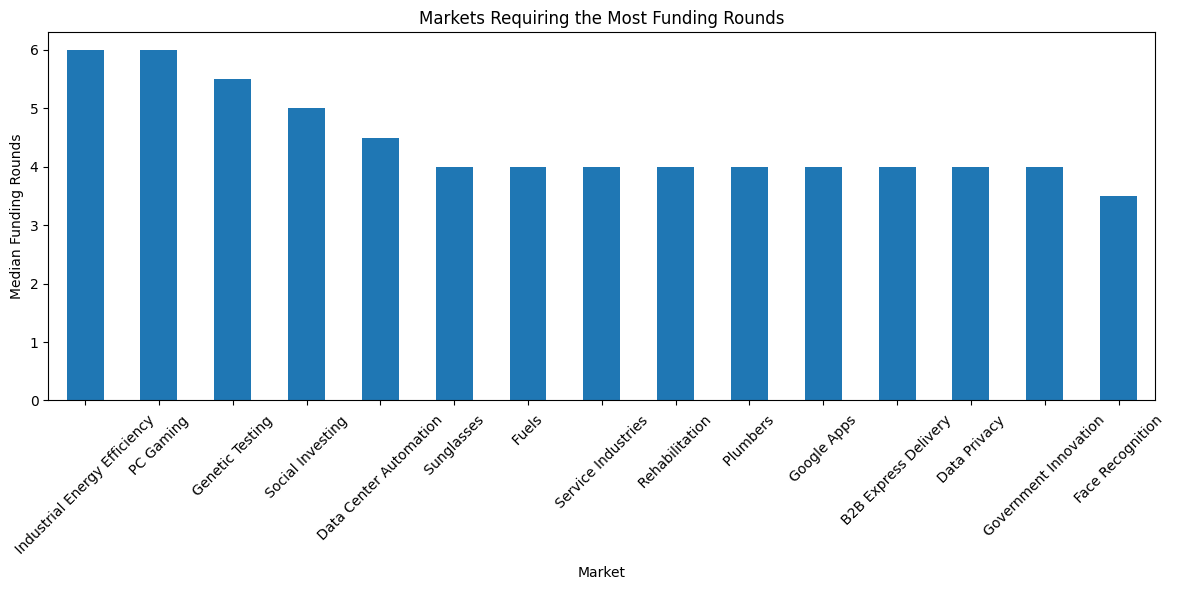

In [14]:
plt.figure(figsize=(12,6))

market_rounds.plot(kind="bar")

plt.title("Markets Requiring the Most Funding Rounds")
plt.xlabel("Market")
plt.ylabel("Median Funding Rounds")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Business Question

Which industries have the highest startup acquisition rates?

### Why This Matters

Acquisition rate measures the percentage of startups that were successfully acquired, providing a useful indicator of market success.

In [15]:
market_total = df["market"].value_counts()

market_acquired = (
    df[df["status"] == "acquired"]["market"]
    .value_counts()
)

acquisition_rate = (
    (market_acquired / market_total) * 100
).dropna()

top_acquisition_rate = (
    acquisition_rate
    .sort_values(ascending=False)
    .head(15)
)

top_acquisition_rate

market
Homeland Security             100.000000
Cable                         100.000000
Neuroscience                   50.000000
Demographies                   50.000000
Digital Rights Management      50.000000
Data Privacy                   50.000000
Displays                       35.714286
Indoor Positioning             33.333333
WebOS                          33.333333
Spas                           33.333333
Trusted Networks               33.333333
iPod Touch                     33.333333
Creative Industries            33.333333
Auto                           33.333333
Virtual Goods                  33.333333
Name: count, dtype: float64

In [16]:
market_total.loc[top_acquisition_rate.index]

market
Homeland Security              1
Cable                          1
Neuroscience                   2
Demographies                   2
Digital Rights Management      2
Data Privacy                   2
Displays                      14
Indoor Positioning             3
WebOS                          3
Spas                           3
Trusted Networks               3
iPod Touch                     3
Creative Industries            3
Auto                           6
Virtual Goods                  3
Name: count, dtype: int64

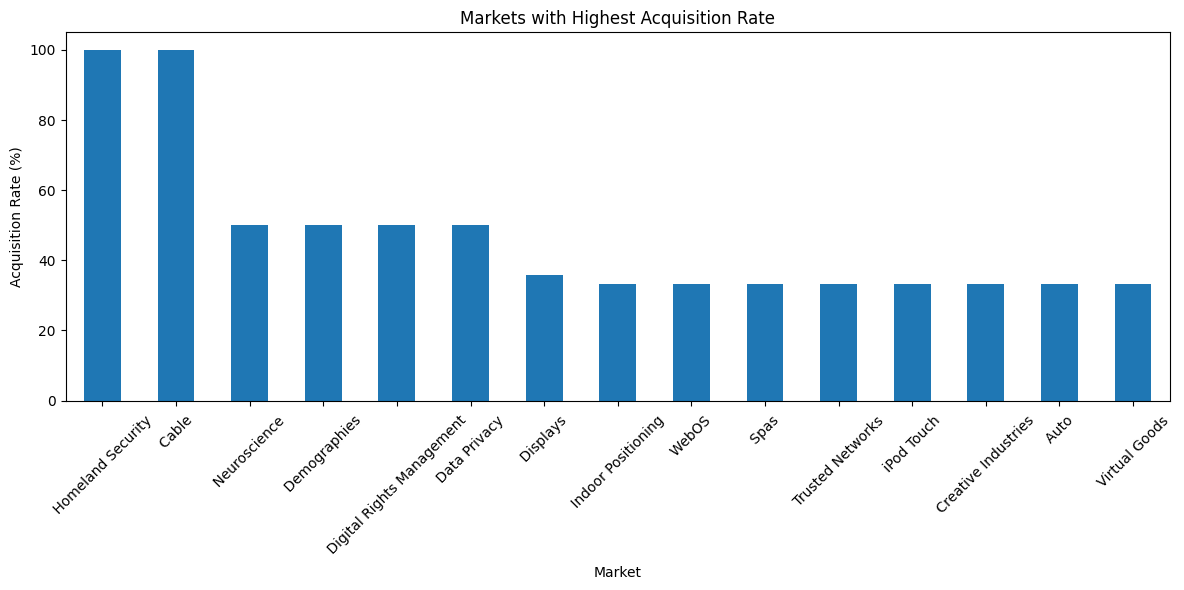

In [17]:
plt.figure(figsize=(12,6))

top_acquisition_rate.plot(kind="bar")

plt.title("Markets with Highest Acquisition Rate")
plt.xlabel("Market")
plt.ylabel("Acquisition Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Business Question

How does startup status vary across different industries?

### Why This Matters

Comparing operating, acquired, and closed startups across markets helps identify industries with stronger long-term performance.

In [18]:
market_status = pd.crosstab(
    df["market"],
    df["status"],
    normalize="index"
) * 100

market_status = market_status.sort_values(
    by="acquired",
    ascending=False
)

market_status.head(15)

status,acquired,closed,operating
market,,,
Homeland Security,100.000000,0.000000,0.000000
Cable,100.000000,0.000000,0.000000
Neuroscience,50.000000,0.000000,50.000000
Digital Rights Management,50.000000,50.000000,0.000000
Data Privacy,50.000000,0.000000,50.000000
Demographies,50.000000,0.000000,50.000000
Displays,35.714286,0.000000,64.285714
Trusted Networks,33.333333,33.333333,33.333333
iPod Touch,33.333333,0.000000,66.666667


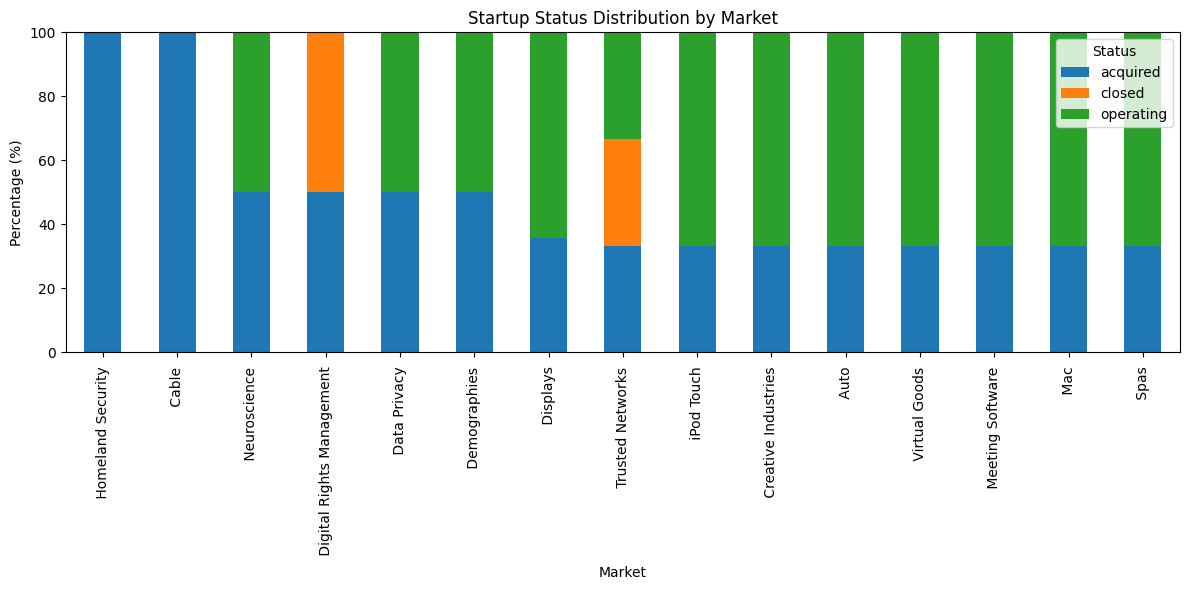

In [19]:
market_status.head(15).plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Startup Status Distribution by Market")
plt.xlabel("Market")
plt.ylabel("Percentage (%)")

plt.legend(title="Status")
plt.tight_layout()

plt.show()